# Mutual Fund Performance Analytics

## Objective

Analyze mutual fund performance using:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Composite Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

In [10]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [3]:
print(nav.columns)
print(benchmark.columns)
print(fund_master.columns)
print(performance.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [4]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03
2026-05-29


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
print(nav["date"].dtype)

datetime64[us]


In [9]:
cagr_1yr = calculate_cagr(nav, 1)
cagr_3yr = calculate_cagr(nav, 3)

In [12]:
print(nav["date"].dtype)

datetime64[us]


In [13]:
cagr_1yr = calculate_cagr(nav, 1)
cagr_3yr = calculate_cagr(nav, 3)

In [14]:
cagr_table = (
    fund_master[
        ["amfi_code", "scheme_name"]
    ]
    .merge(cagr_1yr, on="amfi_code")
    .merge(cagr_3yr, on="amfi_code")
)

In [15]:
cagr_table.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524
1,119552,SBI Bluechip Fund - Direct Plan - Growth,5.706100,16.267372
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922
3,119599,SBI Small Cap Fund - Direct Plan - Growth,13.947803,-1.337387
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.521996,5.840359


In [16]:
print(nav["date"].dtype)
print(cagr_1yr.head())

datetime64[us]
   amfi_code   cagr_1yr
0     100016  -2.224271
1     100025   3.704969
2     100033  53.232396
3     101206  47.924120
4     101207 -23.986032


In [18]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [19]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [20]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [21]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) < 2:
        continue

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - rf) / annual_volatility

    sharpe_results.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [22]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [23]:
print(sharpe_df.shape)

(40, 2)


In [24]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [25]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) < 2:
        continue

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        continue

    annual_return = returns.mean() * 252

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [26]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [27]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

## Insight 4

Sortino Ratio focuses only on downside volatility and highlights funds that generated superior returns while minimizing negative-return risk.

In [28]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [30]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [31]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        ["amfi_code", "date", "daily_return"]
    ]

    fund_df = fund_df[
        fund_df["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [32]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [33]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


## Insight 5

Alpha measures excess return beyond benchmark expectations, while Beta measures market sensitivity. Funds with positive Alpha and moderate Beta demonstrate superior risk-adjusted performance relative to the NIFTY100 benchmark.

In [34]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] / df["running_max"] - 1
    )

    max_dd = df["drawdown"].min()

    worst_row = df.loc[
        df["drawdown"].idxmin()
    ]

    drawdown_results.append([
        fund,
        max_dd,
        worst_row["date"]
    ])

max_dd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_drawdown_date"
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown,worst_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [36]:
max_dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [37]:
max_dd_df.sort_values(
    "max_drawdown"
).head(10)


,amfi_code,max_drawdown,worst_drawdown_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


## Insight 6

Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund. Lower drawdowns indicate stronger downside protection during adverse market conditions.

In [38]:
max_dd_df.head()

,amfi_code,max_drawdown,worst_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [39]:
scorecard = (
    cagr_table[
        ["amfi_code", "cagr_3yr"]
    ]
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "alpha"]
        ],
        on="amfi_code"
    )
    .merge(
        max_dd_df[
            ["amfi_code", "max_drawdown"]
        ],
        on="amfi_code"
    )
    .merge(
        fund_master[
            ["amfi_code", "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,119551,30.456524,1.208267,0.232010,-0.150124,1.54
1,119552,16.267372,0.953279,0.198686,-0.118035,0.66
2,119598,26.669922,0.945308,0.303370,-0.287060,1.43
3,119599,-1.337387,-0.057187,0.048824,-0.525742,0.72
4,119120,5.840359,-0.226575,0.056209,-0.043287,0.77


In [40]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

In [41]:
scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [42]:
scorecard["fund_score"] = (
      30 * scorecard["return_rank"]
    + 25 * scorecard["sharpe_rank"]
    + 20 * scorecard["alpha_rank"]
    + 15 * scorecard["expense_rank"]
    + 10 * scorecard["drawdown_rank"]
)

scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,30.456524,1.208267,0.232010,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,73.0625
1,119552,16.267372,0.953279,0.198686,-0.118035,0.66,0.450,0.725,0.650,0.9250,0.275,61.2500
2,119598,26.669922,0.945308,0.303370,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,75.1250
3,119599,-1.337387,-0.057187,0.048824,-0.525742,0.72,0.075,0.225,0.125,0.8875,1.000,33.6875
4,119120,5.840359,-0.226575,0.056209,-0.043287,0.77,0.225,0.100,0.175,0.8000,0.125,26.0000


In [43]:
scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

In [44]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [45]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
12,120505,31.777537,1.180101,0.292636,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,84.50
26,119094,35.111802,0.998231,0.260767,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,80.75
7,100033,32.442459,1.093699,0.271954,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,80.50
34,148567,34.000916,1.448291,0.269838,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,80.00
22,120843,29.582770,1.306744,0.273305,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,78.25
11,120504,32.487429,1.026524,0.211948,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,75.75
2,119598,26.669922,0.945308,0.303370,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,75.12
39,149324,27.000427,0.949796,0.300579,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,74.94
36,148569,29.178902,1.234930,0.282704,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,73.94
0,119551,30.456524,1.208267,0.232010,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,73.06


## Insight 7

The composite Fund Scorecard combines returns, risk-adjusted performance, benchmark outperformance, expenses, and downside protection into a single ranking metric ranging from 0 to 100.

In [46]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)["amfi_code"]

top5

12    120505
26    119094
7     100033
34    148567
22    120843
Name: amfi_code, dtype: int64

In [47]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

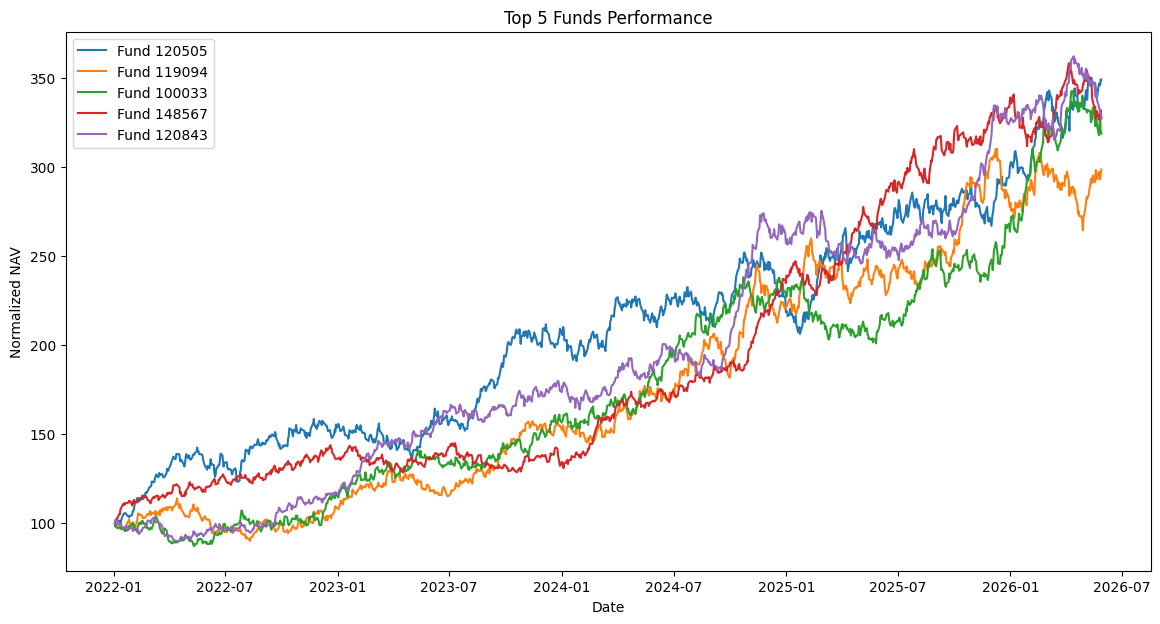

In [48]:
plt.figure(figsize=(14,7))

for fund in top5:

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    normalized = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    plt.plot(
        df["date"],
        normalized,
        label=f"Fund {fund}"
    )

plt.title(
    "Top 5 Funds Performance"
)

plt.xlabel("Date")
plt.ylabel("Normalized NAV")

plt.legend()

plt.show()

In [49]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [52]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [51]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [53]:
tracking_error_df.head()

NameError: name 'tracking_error_df' is not defined

In [54]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [55]:
tracking_error_results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    ).dropna()

    if len(merged) < 30:
        continue

    tracking_error = (
        (merged["daily_return"]
         - merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

In [56]:
tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [57]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [58]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] / df["running_max"] - 1
    )

    trough_idx = df["drawdown"].idxmin()

    trough_date = df.loc[
        trough_idx,
        "date"
    ]

    peak_nav = df.loc[
        :trough_idx,
        "nav"
    ].max()

    peak_date = df.loc[
        df["nav"] == peak_nav,
        "date"
    ].iloc[0]

    max_dd = df["drawdown"].min()

    drawdown_results.append([
        fund,
        max_dd,
        peak_date,
        trough_date
    ])

max_dd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "peak_date",
        "trough_date"
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [59]:
max_dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [60]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

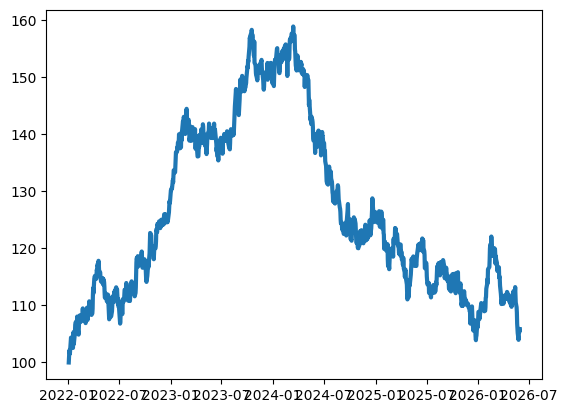

In [61]:
nifty50_norm = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50_norm,
    linewidth=3,
    label="NIFTY50"
)

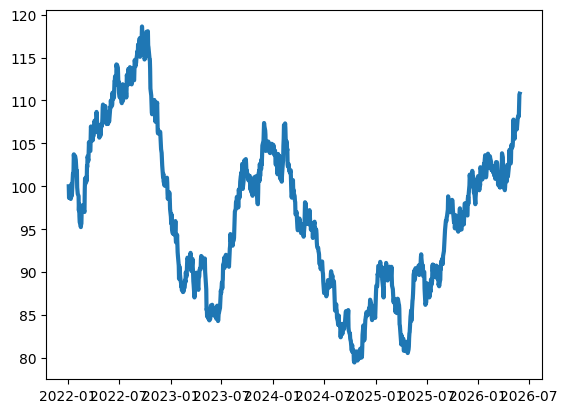

In [62]:
nifty100_norm = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100_norm,
    linewidth=3,
    label="NIFTY100"
)

In [63]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Note on 5-Year CAGR

The NAV history dataset spans January 2022 to May 2026, which is insufficient to calculate a true 5-year CAGR. Therefore, only 1-year and 3-year CAGR metrics are reported.